In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
try:
    df = pd.read_csv('loan_data.csv')
except FileNotFoundError:
    print("Error: File 'loan_data.csv' not found.")
    # Additional fallback logic or end if essential file
    raise

df.dropna(inplace=True)
df.drop_duplicates()

print("First 5 rows:")
print(df.head())
print("\ndataset info:")
df.info()

# 1. Feature Transformation: Transform 'purpose' (categorical) usgin One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['purpose'], drop_first=True)

# Verificar o resultado do One-Hot Encoding
print("\nColumns post One-Hot Encoding:")
print(df_encoded.columns)


Target feature distribution (not.fully.paid):
0    8045
1    1533
Name: not.fully.paid, dtype: int64


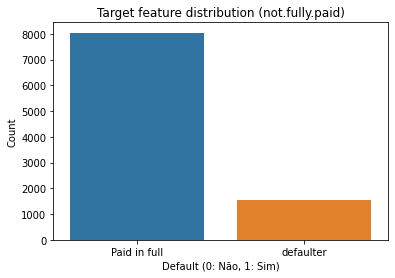


Defaulting Tax: 16.01%


In [ ]:
# Variable count for the target feature
target_counts = df_encoded['not.fully.paid'].value_counts()
print("\nTarget feature distribution (not.fully.paid):")
print(target_counts)

# Unbalanced class visualization
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Target feature distribution (not.fully.paid)')
plt.xlabel('Default (0: Não, 1: Sim)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Paid in full', 'defaulter'])
plt.show()

# Defaulting porcentage calc
default_rate = target_counts[1] / target_counts.sum()
print(f"\nDefaulting Tax: {default_rate*100:.2f}%")

In [ ]:
#2. Correlation Analysis

# Correlation Matrix
plt.figure(figsize=(18, 15))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('All features Matrix')
plt.show()

In [ ]:
# 3. Feature Engineering: Removal of Correlated Features

# Create a correlation matrix (upper triangle only to avoid duplicates)
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find columns with correlation greater than 0.80
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print("\nColumns to be removed due to high correlation (> 0.80):")
print(to_drop)

# Remove the identified columns
df_final = df_encoded.drop(columns=to_drop)

print(f"\nNumber of columns before: {df_encoded.shape[1]}")
print(f"Number of columns after: {df_final.shape[1]}")

print("\nThe remaining columns for modeling are:")
print(df_final.columns.tolist())



Columns to be removed due to high correlation (> 0.80):
[]

Number of columns before: 19
Number of columns after: 19

The remaining columns for modeling are:
['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_small_business']


In [ ]:
# 4. Modeling

# Variables X e Y
X = df_final.drop('not.fully.paid', axis=1)
y = df_final['not.fully.paid']

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Data scaling
# Deep Learning benefits greatly from the scaling of numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData ready for the model. Training Mode:", X_train.shape)


Data ready for the model. Training Mode: (6704, 18)


In [ ]:
# Set the number of input features
input_dim = X_train.shape[1]

# Keras model construction
model = Sequential([
    # Input Layer
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3), #Dropout to avoid overfitting

    # Hidden Layer 1
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid') # Sigmoid activation for binary classification
])

# Model Compilation
# I'm using 'binary_crossentropy' for the binary classification problem
model.compile(optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

print("\nStructure of the Deep Learning Model:")
model.summary()

# Model Training
print("\nStarting Model Training...")
history=model.fit(X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1, # Use 10% of training data for validation
    verbose=0) # Set as 1 or 2 to see the training progress
print("Training conluded.")


Structure of the Deep Learning Model:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 128)               2432      
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_7 (Dense

90/90 [==============================] - 0s 637us/step

--- Deep Learning Model Evaluation ---
Area Under ROC Curve (AUC): 0.6612n
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2414
           1       0.39      0.03      0.06       460

    accuracy                           0.84      2874
   macro avg       0.62      0.51      0.49      2874
weighted avg       0.77      0.84      0.78      2874



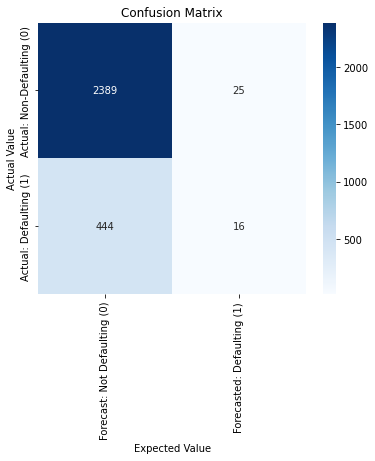


Confusion Matrix:
True Negatives (TN): 2389
False Positives (FP): 25
False Negatives (FN): 444
True Positives (TP): 16


In [ ]:
# Predictions in the test set (probabilities)
y_pred_proba = model.predict(X_test)
# Convert probabilities to binary classes (0 or 1) with a default threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype("int32")

# Rating
print("\n--- Deep Learning Model Evaluation ---")

# AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Area Under ROC Curve (AUC): {roc_auc:.4f}n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Forecast: Not Defaulting (0)', 'Forecasted: Defaulting (1)'],
    yticklabels=['Actual: Non-Defaulting (0)', 'Actual: Defaulting (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Value')
plt.xlabel('Expected Value')
plt.show()

print("\nConfusion Matrix:")
print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")

### The AUC (Area Under the ROC Curve) result is the most reliable metric for this imbalanced problem, as it evaluates performance across all classification thresholds.

# Summary of Steps Performed:

### 1. Feature Transformation:
I used pd.get_dummies to transform the categorical column 'purpose' into binary numerical features (One-Hot Encoding).
### 2. Exploratory Data Analysis (EDA):
I identified a strong class imbalance in the target variable (not.fully.paid), with only 16% default.
### 3. Additional Feature Engineering:
I calculated the correlation matrix and, if there were feature pairs with correlation $ > 0.80$, I removed one of them to reduce multicollinearity.
### 4. Modeling:
I split the data into training and test sets and performed scaling using StandardScaler.
Built a Deep Learning (DNN) model using Keras with 3 hidden layers and Dropout for regularization.
And trained the model using binary_crossentropy, evaluated the model using AUC and the Classification Report, which are more suitable for the imbalanced dataset.